Точка отсчета: 0.8170

***Генерация признаков***:

1)Добавил минимумы, максимумы и отклонения сум обычных и со скидкой, количество действий и времена между действиями. Результат +0.035

2)Проанализировал данные. Понял, что распределение прошедешего времени с первой покупки распределено на тесте не так, как на трейне. Выкинул эту фичу. Еще ограничил количество объектов в листе. Результат +0.01.


***Интерпретация бустинга.***

Разбил вручную выборку, исходя из того, какую задачу чаще всего выполнял бустинг в вершинах деревьев. Обучил несколько моделей на подгруппах. Результата не принесло.

***Понижение размерности***

Попробовал использовать UMAP для понижения размерности и получения эмбеддингов объектов, чтобы на них уже обучить бустинг. Результата не принесло.

***Тюнинг гиперпараметров***

Использовал оптуну. Результат +0.005
Позже использовал катбуст вместо лгбм. Результат +0.001

In [20]:
import polars as pl
import pandas as pd
import numpy as np
import catboost
import lightgbm as lgb
import os
from datetime import date, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import umap

In [21]:
import warnings
 
warnings.filterwarnings("ignore")

In [22]:
test_start_date = date(2024, 8, 1)
val_start_date = date(2024, 7, 1)
val_end_date = date(2024, 7, 31)
train_end_date = date(2024, 6, 30)

# Read data

In [3]:
actions_history = pl.read_parquet('actions_history')
search_history = pl.read_parquet('search_history')
product_information = pl.read_csv('product_information.csv')

In [4]:
val_target = (
    actions_history
    .filter(pl.col('timestamp').dt.date() >= val_start_date)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .select('user_id', (pl.col('action_type_id') == 3).alias('has_order'))
    .group_by('user_id')
    .agg(pl.max('has_order').cast(pl.Int32).alias('target'))
)

# Пайплайн с лучшим скором

### Считаю продуктовые фичи

In [4]:
product_features = product_information.filter(pl.col('price')!=0).drop(['name', 'type', 'category_name'])
product_features = product_features.with_columns(((pl.col('price') - pl.col('discount_price')) / pl.col('price')).alias('discount_percent').fill_nan(0))

In [5]:
product_features = product_features.join(product_features.group_by('category_id').agg(pl.mean('price').alias('mean_price_category'),
                                             pl.std('price').alias('std_price_category'),
                                             pl.max('price').alias('max_price_category'),
                                             pl.min('price').alias('min_price_category'),
                                             pl.mean('discount_price').alias('mean_discount_price_category'),
                                             pl.std('discount_price').alias('std_discount_price_category'),
                                             pl.max('discount_price').alias('max_discount_price_category'),
                                             pl.min('discount_price').alias('min_discount_price_category'),
                                             pl.mean('discount_percent').alias('mean_discount_percent_category'),
                                             pl.std('discount_percent').alias('std_discount_percent_category'),
                                             pl.max('discount_percent').alias('max_discount_percent_category'),
                                             pl.count('product_id').alias('category_size'),
                                             pl.col('brand').unique().count().alias('brands_num')), on='category_id', how='left')

product_features = product_features.join(product_features.group_by('brand').agg(pl.count('product_id').alias('brand_size'),
                                      pl.col('category_id').unique().count().alias('brand_category_num')), on='brand', how='left')

product_features = product_features.with_columns(((pl.col('price') - pl.col('mean_price_category')) / pl.col('price')).alias('mean_category_diff'),
                             ((pl.col('discount_percent') - pl.col('mean_discount_percent_category')) / pl.col('discount_percent')).alias('mean_discount_category_diff')).drop('brand')

In [51]:
product_features.write_parquet("product_features.parquet")

In [62]:
product_features = pl.read_parquet("product_features.parquet")

### Далее считаю фичи действий пользователя

In [4]:
actions_features = pl.read_parquet("actions_history") \
                    .filter(pl.col('timestamp').dt.date() <= train_end_date) \
                    .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))

In [5]:
actions_aggs = {}
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    5: "to_cart",
}
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_features.filter(pl.col('action_type_id') == id_)
                .join(product_features, on='product_id', how='left')
                .group_by('user_id')
                .agg(
                pl.count('product_id').alias(f'{suf}_num'),
                pl.col('product_id').unique().count().alias(f'{suf}_unique_num'),
                pl.col('page_product_id').is_null().sum().alias(f'{suf}_chained_num'),
                pl.col('page_product_id').is_null().mean().alias(f'{suf}_chained_freq'),
                pl.col('widget_name_id').mode().first().alias(f'{suf}_max_freq_widget'),
                pl.sum('price').alias(f'{suf}_sum_price'),
                pl.max('price').alias(f'{suf}_max_price'),
                pl.min('price').alias(f'{suf}_min_price'),
                pl.mean('price').alias(f'{suf}_mean_price'),
                pl.sum('discount_price').alias(f'{suf}_discount_sum'),
                pl.max('discount_price').alias(f'{suf}_discount_max'),
                pl.min('discount_price').alias(f'{suf}_discount_min'),
                pl.mean('discount_price').alias(f'{suf}_discount_mean'),
                pl.col('category_id').unique().count().alias(f'{suf}_category_num'),
                pl.col('category_id').mode().first().alias(f'{suf}_max_freq_category'),
                pl.col('timestamp').dt.truncate('1d').unique().count().alias(f'{suf}_day_num'),
                pl.col('timestamp').sort().diff().mean().dt.total_days().fill_null(0).alias(f'{suf}_day_diff_mean'),
                pl.max('timestamp').alias(f'last_{suf}_time'),
                pl.min('timestamp').alias(f'first_{suf}_time'),
                )
            .with_columns([
            (pl.lit(val_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(val_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
            ]).drop(
                [f'last_{suf}_time', f'first_{suf}_time']
            )
        )
    actions_aggs[id_] = aggs

In [7]:
actions_history = pl.read_parquet('actions_history')
val_target = (
    actions_history
    .filter(pl.col('timestamp').dt.date() >= val_start_date)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .select('user_id', (pl.col('action_type_id') == 3).alias('has_order'))
    .group_by('user_id')
    .agg(pl.max('has_order').cast(pl.Int32).alias('target'))
)

In [8]:
df = val_target
for _, actions_aggs_df in actions_aggs.items():
    df = (
        df
        .join(actions_aggs_df, on='user_id', how='left')
    )

In [9]:
df.write_parquet("tmp_actions_features_val.parquet")

 ### Считаю фичи поиска

In [3]:
search_history = pl.read_parquet('search_history').filter(pl.col('timestamp').dt.date() <= train_end_date) \
                    .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))

In [4]:
id_ = 4
search_features = (search_history.filter(pl.col('action_type_id') == id_)
                .group_by('user_id')
                .agg(
                pl.count('timestamp').alias('search_num'),
                pl.col('search_query').unique().count().alias('search_unique_num'),
                pl.col('widget_name_id').mode().first().alias('search_max_freq_widget'),
                pl.col('timestamp').dt.truncate('1d').unique().count().alias('search_day_num'),
                )
)

In [6]:
search_features.write_parquet("search_val1.parquet")

In [7]:
id_ = 4
search_features = (search_history.filter(pl.col('action_type_id') == id_)
                .group_by('user_id')
                .agg(
                pl.col('timestamp').sort().diff().mean().dt.total_days().fill_null(0).alias('search_day_diff_mean'),
                pl.max('timestamp').alias('last_search_time'),
                pl.min('timestamp').alias('first_search_time'),
                )
            .with_columns([
            (pl.lit(val_start_date) - pl.col('last_search_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias('days_since_last_search'),

            (pl.lit(val_start_date) - pl.col('first_search_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias('days_since_first_search'),
            ]).drop(
                ['last_search_time', 'first_search_time']
            )
)

Здесь я сохраняю фичи чтобы не пересчитывать позже. Считалось долго и сжирало много памяти.

In [9]:
search_features.write_parquet("search_val2.parquet")
search_features = pl.read_parquet("search_val1.parquet").join(pl.read_parquet("search_val2.parquet"), on='user_id', how='left')
search_features.write_parquet("search_val.parquet")
df = pl.read_parquet("tmp_actions_features_val.parquet")
df = df.join(search_features, on='user_id', how='left')
df.write_parquet("tmp_features_val.parquet")

In [23]:
df = pl.read_parquet("tmp_features_val.parquet")

In [24]:
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    4: "search",
    5: "to_cart",
}

In [25]:
for _, suf in actions_id_to_suf.items():
    df = df.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )
    if suf != "search":
        df = df.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_chained_num').fill_null(0),
                         pl.col(f'{suf}_chained_freq').fill_null(0),
                         pl.col(f'{suf}_sum_price').fill_null(0),
                         pl.col(f'{suf}_max_price').fill_null(0),
                         pl.col(f'{suf}_min_price').fill_null(0),
                         pl.col(f'{suf}_mean_price').fill_null(0),
                         pl.col(f'{suf}_discount_sum').fill_null(0),
                         pl.col(f'{suf}_discount_max').fill_null(0),
                         pl.col(f'{suf}_discount_min').fill_null(0),
                         pl.col(f'{suf}_discount_mean').fill_null(0),
                         pl.col(f'{suf}_category_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )

### Обучение модельки

In [26]:
train_pool = catboost.Pool(
    train_data_pd.drop(['user_id', 'target', 'days_since_first_order'], axis=1),
    label=train_data_pd['target']
)

params = {
    'iterations': 200,
    'depth': 8, 
    'random_state': 1,
    'loss_function': 'Logloss',
    'task_type': 'CPU',
    'eta': 0.12267070991041436,
    'verbose': 0
}

In [27]:
model = catboost.CatBoost(params)
model.fit(
    train_pool
)

### код для подсчета фичей теста и предсказание

In [59]:
test_users_submission = (pl.read_csv('test_users.csv'))

In [60]:
actions_features_test = pl.read_parquet("actions_history") \
                    .filter(pl.col('timestamp').dt.date() <= val_end_date) \
                    .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))

In [63]:
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_features_test.filter(pl.col('action_type_id') == id_)
                .join(product_features, on='product_id', how='left')
                .group_by('user_id')
                .agg(
                pl.count('product_id').alias(f'{suf}_num'),
                pl.col('product_id').unique().count().alias(f'{suf}_unique_num'),
                pl.col('page_product_id').is_null().sum().alias(f'{suf}_chained_num'),
                pl.col('page_product_id').is_null().mean().alias(f'{suf}_chained_freq'),
                pl.col('widget_name_id').mode().first().alias(f'{suf}_max_freq_widget'),
                pl.sum('price').alias(f'{suf}_sum_price'),
                pl.max('price').alias(f'{suf}_max_price'),
                pl.min('price').alias(f'{suf}_min_price'),
                pl.mean('price').alias(f'{suf}_mean_price'),
                pl.sum('discount_price').alias(f'{suf}_discount_sum'),
                pl.max('discount_price').alias(f'{suf}_discount_max'),
                pl.min('discount_price').alias(f'{suf}_discount_min'),
                pl.mean('discount_price').alias(f'{suf}_discount_mean'),
                pl.col('category_id').unique().count().alias(f'{suf}_category_num'),
                pl.col('category_id').mode().first().alias(f'{suf}_max_freq_category'),
                pl.col('timestamp').dt.truncate('1d').unique().count().alias(f'{suf}_day_num'),
                pl.col('timestamp').sort().diff().mean().dt.total_days().fill_null(0).alias(f'{suf}_day_diff_mean'),
                pl.max('timestamp').alias(f'last_{suf}_time'),
                pl.min('timestamp').alias(f'first_{suf}_time'),
                )
            .with_columns([
            (pl.lit(test_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(test_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
            ]).drop(
                [f'last_{suf}_time', f'first_{suf}_time']
            )
        )
    actions_aggs[id_] = aggs

In [64]:
df = test_users_submission.with_columns(pl.col("user_id").cast(pl.Int32))
for _, actions_aggs_df in actions_aggs.items():
    df = (df.join(actions_aggs_df, on='user_id', how='left'))

In [66]:
df.write_parquet("tmp_actions_features_test.parquet")

In [3]:
search_history = pl.read_parquet('search_history').filter(pl.col('timestamp').dt.date() <= val_end_date) \
                    .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))

In [4]:
id_ = 4
search_features = (search_history.filter(pl.col('action_type_id') == id_)
                .group_by('user_id')
                .agg(
                pl.count('timestamp').alias('search_num'),
                pl.col('search_query').unique().count().alias('search_unique_num'),
                )
)

In [5]:
search_features.write_parquet("search_test1.parquet")

In [6]:
id_ = 4
search_features = (search_history.filter(pl.col('action_type_id') == id_)
                .group_by('user_id')
                .agg(
                pl.col('widget_name_id').mode().first().alias('search_max_freq_widget'),
                pl.col('timestamp').dt.truncate('1d').unique().count().alias('search_day_num'),
                )
)

In [7]:
search_features.write_parquet("search_test2.parquet")

In [8]:
id_ = 4
search_features = (search_history.filter(pl.col('action_type_id') == id_)
                .group_by('user_id')
                .agg(
                pl.col('timestamp').sort().diff().mean().dt.total_days().fill_null(0).alias('search_day_diff_mean'),
                pl.max('timestamp').alias('last_search_time'),
                pl.min('timestamp').alias('first_search_time'),
                )
            .with_columns([
            (pl.lit(test_start_date) - pl.col('last_search_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias('days_since_last_search'),

            (pl.lit(test_start_date) - pl.col('first_search_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias('days_since_first_search'),
            ]).drop(
                ['last_search_time', 'first_search_time']
            )
)

In [9]:
search_features.write_parquet("search_test3.parquet")
search_features = pl.read_parquet("search_test1.parquet").join(pl.read_parquet("search_test2.parquet"), on='user_id', how='left')
search_features = search_features.join(pl.read_parquet("search_test3.parquet"), on='user_id', how='left')
search_features.write_parquet("search_test.parquet")

In [28]:
search_features = pl.read_parquet("search_test.parquet")
df = pl.read_parquet("tmp_actions_features_test.parquet")
df = df.join(search_features, on='user_id', how='left')

In [29]:
for _, suf in actions_id_to_suf.items():
    df = df.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )
    if suf != "search":
        df = df.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_chained_num').fill_null(0),
                         pl.col(f'{suf}_chained_freq').fill_null(0),
                         pl.col(f'{suf}_sum_price').fill_null(0),
                         pl.col(f'{suf}_max_price').fill_null(0),
                         pl.col(f'{suf}_min_price').fill_null(0),
                         pl.col(f'{suf}_mean_price').fill_null(0),
                         pl.col(f'{suf}_discount_sum').fill_null(0),
                         pl.col(f'{suf}_discount_max').fill_null(0),
                         pl.col(f'{suf}_discount_min').fill_null(0),
                         pl.col(f'{suf}_discount_mean').fill_null(0),
                         pl.col(f'{suf}_category_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )

In [31]:
df_pd = df.to_pandas()

In [32]:
df_pd['predict'] = model.predict(df_pd.drop(['user_id', 'days_since_first_order'], axis=1), prediction_type="Probability")[:, 1]

In [33]:
df_pd[['user_id', 'predict']].to_csv('my_submission.csv', index=False)

# Data Explore

In [4]:
train_data = pl.read_parquet("tmp_features_val.parquet")
search_features = pl.read_parquet("search_test.parquet")
test_data = pl.read_parquet("tmp_actions_features_test.parquet")
test_data = test_data.join(search_features, on='user_id', how='left')

In [5]:
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    4: "search",
    5: "to_cart",
}

for _, suf in actions_id_to_suf.items():
    train_data = train_data.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )
    test_data = test_data.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )
    if suf != "search":
        train_data = train_data.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_chained_num').fill_null(0),
                         pl.col(f'{suf}_chained_freq').fill_null(0),
                         pl.col(f'{suf}_sum_price').fill_null(0),
                         pl.col(f'{suf}_max_price').fill_null(0),
                         pl.col(f'{suf}_min_price').fill_null(0),
                         pl.col(f'{suf}_mean_price').fill_null(0),
                         pl.col(f'{suf}_discount_sum').fill_null(0),
                         pl.col(f'{suf}_discount_max').fill_null(0),
                         pl.col(f'{suf}_discount_min').fill_null(0),
                         pl.col(f'{suf}_discount_mean').fill_null(0),
                         pl.col(f'{suf}_category_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )
        test_data = test_data.with_columns(pl.col(f'{suf}_num').fill_null(0),
                         pl.col(f'{suf}_unique_num').fill_null(0),
                         pl.col(f'{suf}_chained_num').fill_null(0),
                         pl.col(f'{suf}_chained_freq').fill_null(0),
                         pl.col(f'{suf}_sum_price').fill_null(0),
                         pl.col(f'{suf}_max_price').fill_null(0),
                         pl.col(f'{suf}_min_price').fill_null(0),
                         pl.col(f'{suf}_mean_price').fill_null(0),
                         pl.col(f'{suf}_discount_sum').fill_null(0),
                         pl.col(f'{suf}_discount_max').fill_null(0),
                         pl.col(f'{suf}_discount_min').fill_null(0),
                         pl.col(f'{suf}_discount_mean').fill_null(0),
                         pl.col(f'{suf}_category_num').fill_null(0),
                         pl.col(f'{suf}_day_num').fill_null(0)
                        )

In [6]:
train_data_pd = train_data.to_pandas()
test_data_pd = test_data.to_pandas()

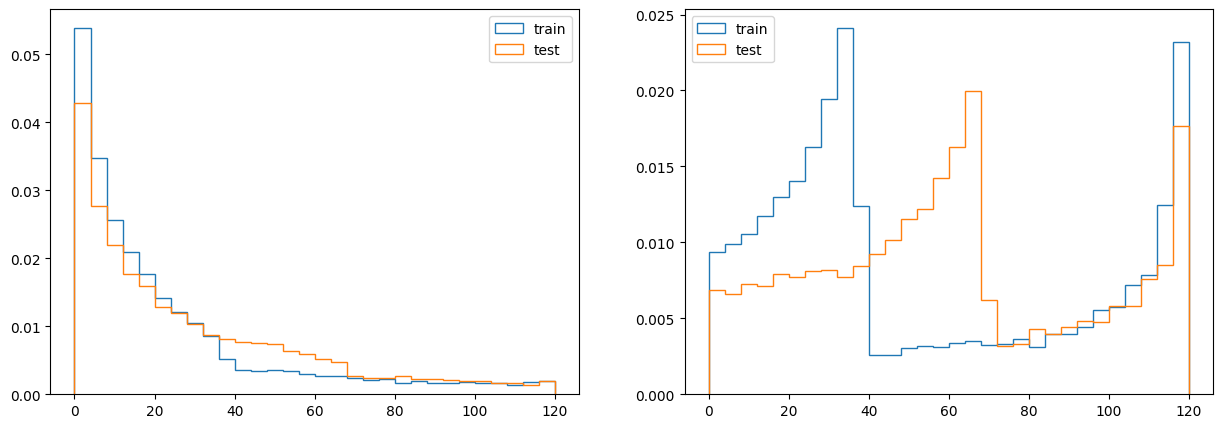

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_data_pd['days_since_last_order'], bins=30, histtype='step', label='train', density=True)
axes[0].hist(test_data_pd['days_since_last_order'], bins=30, histtype='step', label='test', density=True)
axes[0].legend()

axes[1].hist(train_data_pd['days_since_first_order'], bins=30, histtype='step', label='train', density=True)
axes[1].hist(test_data_pd['days_since_first_order'], bins=30, histtype='step', label='test', density=True)
axes[1].legend()

plt.show()

### Вижу, что распределение данных сильно отличается у фичи days_since_first_order. Позже я выкину эту фичу.

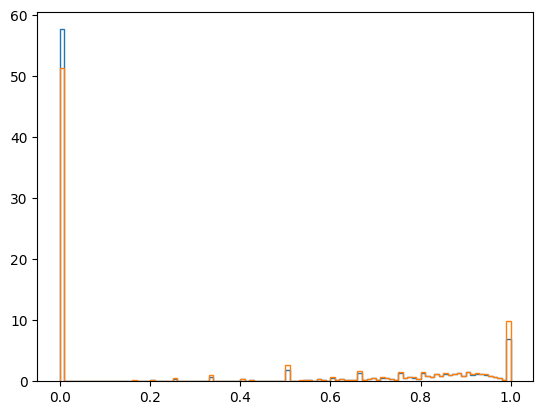

In [50]:
plt.hist(train_data_pd['to_cart_chained_freq'], bins=100, density=True, histtype='step')
plt.hist(test_data_pd['to_cart_chained_freq'], bins=100, density=True, histtype='step')
plt.show()

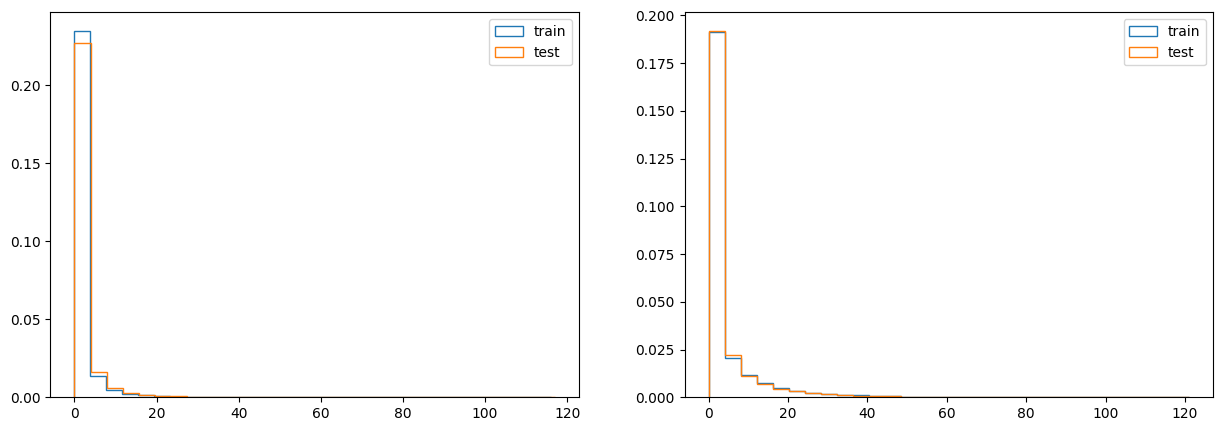

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_data_pd['order_day_num'], bins=30, histtype='step', label='train', density=True)
axes[0].hist(test_data_pd['order_day_num'], bins=30, histtype='step', label='test', density=True)
axes[0].legend()

axes[1].hist(train_data_pd['to_cart_day_num'], bins=30, histtype='step', label='train', density=True)
axes[1].hist(test_data_pd['to_cart_day_num'], bins=30, histtype='step', label='test', density=True)
axes[1].legend()

plt.show()

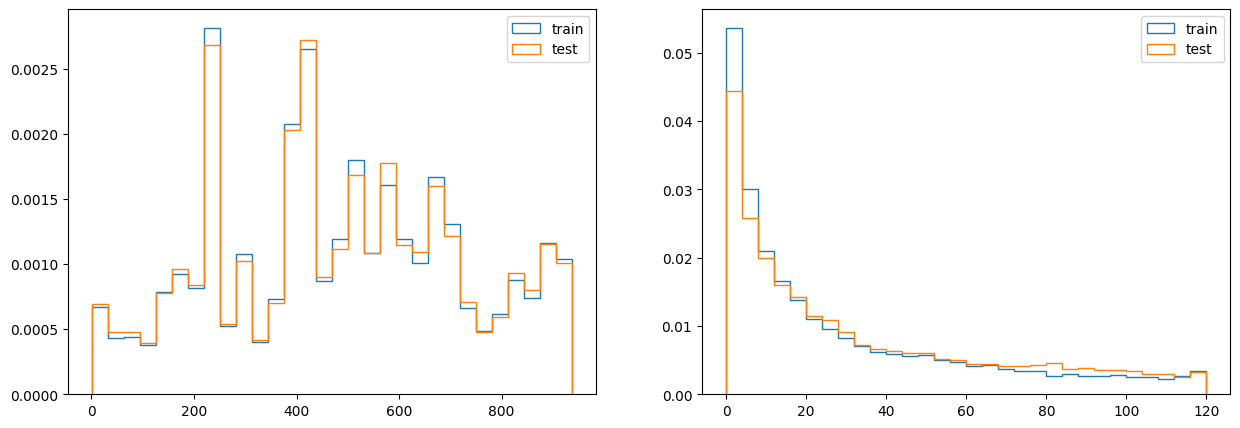

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_data_pd['to_cart_max_freq_category'], bins=30, histtype='step', label='train', density=True)
axes[0].hist(test_data_pd['to_cart_max_freq_category'], bins=30, histtype='step', label='test', density=True)
axes[0].legend()

axes[1].hist(train_data_pd['days_since_last_to_cart'], bins=30, histtype='step', label='train', density=True)
axes[1].hist(test_data_pd['days_since_last_to_cart'], bins=30, histtype='step', label='test', density=True)
axes[1].legend()

plt.show()

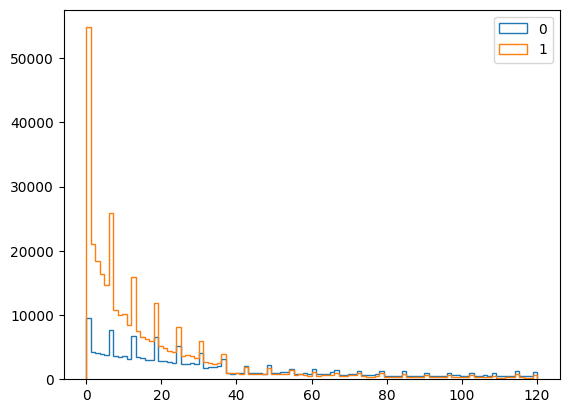

In [64]:
plt.hist(train_data_pd[train_data_pd['target'] == 0]['days_since_last_order'], label='0', histtype='step', bins=100)
plt.hist(train_data_pd[train_data_pd['target'] == 1]['days_since_last_order'], label='1', histtype='step', bins=100)
plt.legend()
plt.show()

### Видно что тут можно разбить данные по порогу 40

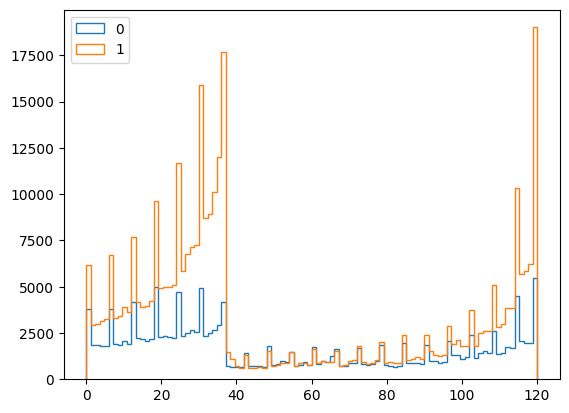

In [65]:
plt.hist(train_data_pd[train_data_pd['target'] == 0]['days_since_first_order'], label='0', histtype='step', bins=100)
plt.hist(train_data_pd[train_data_pd['target'] == 1]['days_since_first_order'], label='1', histtype='step', bins=100)
plt.legend()
plt.show()

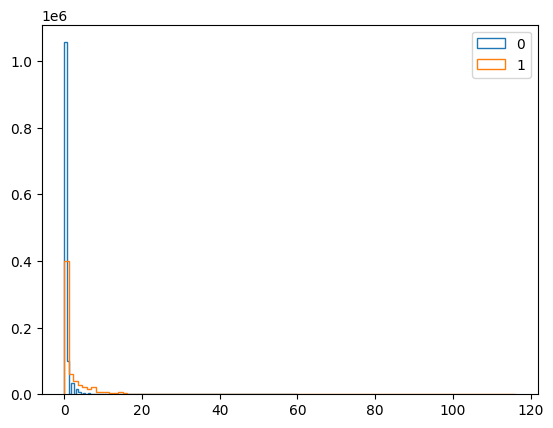

In [129]:
plt.hist(train_data_pd[train_data_pd['target'] == 0]['order_day_num'], label='0', histtype='step', bins=100)
plt.hist(train_data_pd[train_data_pd['target'] == 1]['order_day_num'], label='1', histtype='step', bins=100)
plt.legend()
plt.show()

# Interpretation

### Посмотрим, что внутри бустинга.

In [8]:
mask = train_data_pd.user_id % 10 <= 7
X_tr = train_data_pd.loc[mask].drop(['user_id', 'target', 'days_since_first_order'], axis=1)
y_tr = train_data_pd.loc[mask].target
X_val = train_data_pd.loc[~mask].drop(['user_id', 'target', 'days_since_first_order'], axis=1)
y_val = train_data_pd.loc[~mask].target

In [9]:
lgb_tr = lgb.Dataset(X_tr, y_tr, free_raw_data=False)#, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val, y_val, free_raw_data=False)#, reference=lgb_tr)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'eta': 0.1,
    'lambda': 1e-3,
    'early_stopping_round': 40,
    'seed': 42,
    'num_threads': 0,
    'verbosity': 1,
    'max_depth': -1
}

In [21]:
model = lgb.train(
    params, lgb_tr, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr, lgb_val],
)

[LightGBM] [Info] Number of positive: 518252, number of negative: 981495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.743797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15772
[LightGBM] [Info] Number of data points in the train set: 1499747, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.345560 -> initscore=-0.638615
[LightGBM] [Info] Start training from score -0.638615
Training until validation scores don't improve for 40 rounds
Did not meet early stopping. Best iteration is:
[199]	train's auc: 0.766003	valid's auc: 0.763599


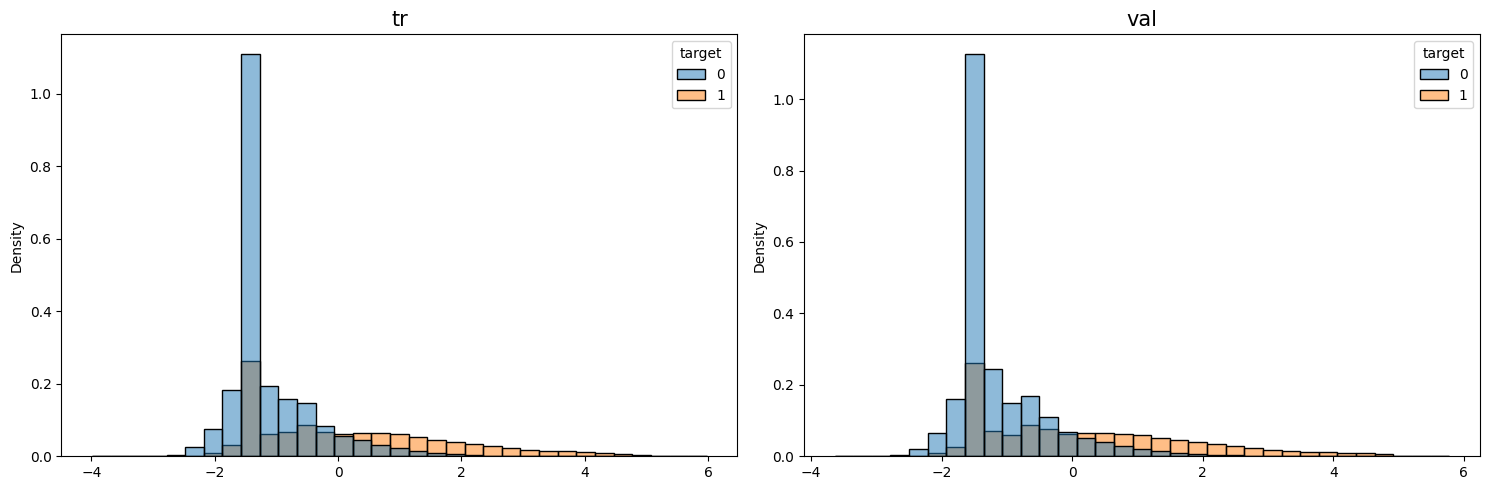

In [107]:
y_pred_tr_raw = model.predict(X_tr, raw_score=True)
y_pred_val_raw = model.predict(X_val, raw_score=True)

mosaic = [['tr', 'val']]
fig, ax = plt.subplot_mosaic(mosaic, figsize=(15, 5))
for key in ax:
    ax[key].set_title(key, fontsize=15)

sns.histplot(x=y_pred_tr_raw, hue=y_tr, bins=33, ax=ax['tr'], stat='density')
sns.histplot(x=y_pred_val_raw, hue=y_val, bins=33, ax=ax['val'], stat='density')
fig.tight_layout()

plt.show()

### Распределение логитов схожее. Кажется, что данные валидации и трейна не сильно отличаются. Это хорошо, данных взяли достаточно для обучения.

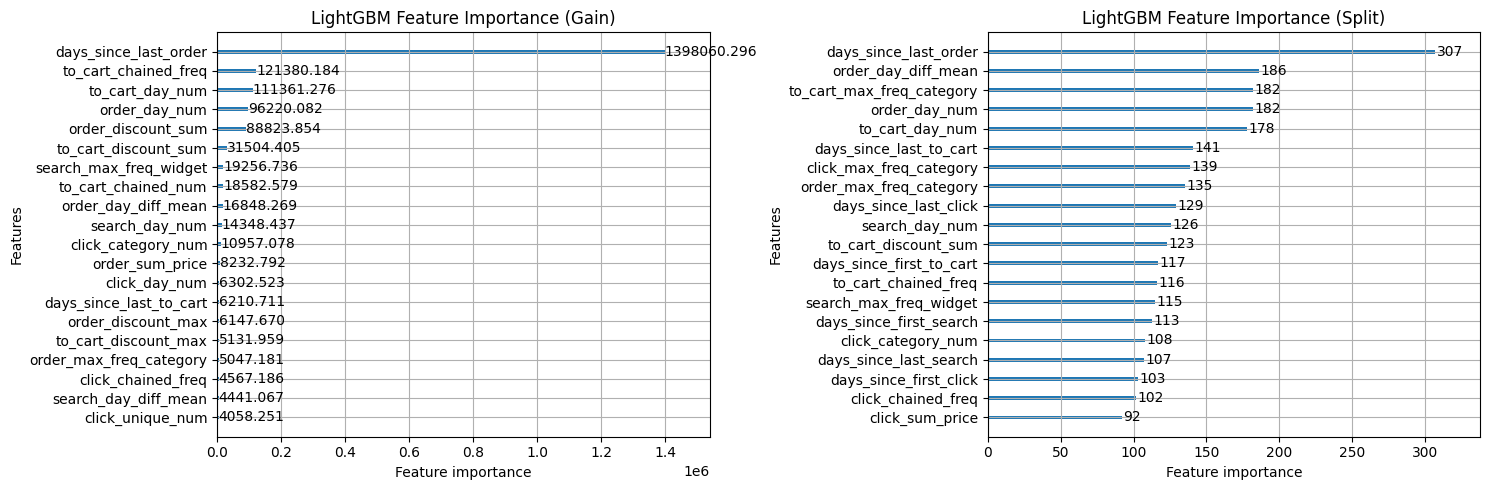

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

lgb.plot_importance(model, importance_type="gain", 
                    title="LightGBM Feature Importance (Gain)",
                    max_num_features=20, ax=ax[0])

lgb.plot_importance(model, importance_type="split",
                    title="LightGBM Feature Importance (Split)",
                    max_num_features=20, ax=ax[1])

plt.tight_layout()
plt.show()

### Здесь мы видим важности фичей. Одна из фичей преобладает над остальными.

In [23]:
t = model.trees_to_dataframe()
t[t['node_depth'] == 1]

,tree_index,node_depth,node_index,left_child,right_child,parent_index,split_feature,split_gain,threshold,decision_type,missing_direction,missing_type,value,weight,count
0,0,1,0-S0,0-S2,0-S1,None,days_since_last_order,281241.00000,40.5,<=,right,NaN,-0.638615,0.0,1499747
61,1,1,1-S0,1-S2,1-S1,None,days_since_last_order,220287.00000,46.5,<=,right,NaN,0.000000,0.0,1499747
122,2,1,2-S0,2-S2,2-S1,None,days_since_last_order,175494.00000,44.5,<=,right,NaN,0.000000,0.0,1499747
183,3,1,3-S0,3-S2,3-S1,None,days_since_last_order,141465.00000,39.5,<=,right,NaN,0.000000,0.0,1499747
244,4,1,4-S0,4-S2,4-S1,None,days_since_last_order,114779.00000,57.5,<=,right,NaN,0.000000,0.0,1499747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11834,194,1,194-S0,194-L0,194-S1,None,search_max_freq_widget,3.24729,25.0,<=,left,NaN,0.000000,0.0,1499747
11895,195,1,195-S0,195-S5,195-S1,None,order_unique_num,3.22417,253.5,<=,left,None,0.000000,0.0,1499747
11956,196,1,196-S0,196-S12,196-S1,None,order_category_num,3.26011,99.5,<=,left,None,0.000000,0.0,1499747
12017,197,1,197-S0,197-S1,197-S3,None,order_day_num,3.29434,3.5,<=,left,None,0.000000,0.0,1499747


### Как видим, по фиче days_since_last_order часто делается сплит. Также как и по order_num. Деревья решают одну и ту же задачу. Что если засплитить данные по этим фичам изначально, а бустингам дать остальные данные? Спойлер - не помогло. Некоторые сплиты данных маленькие, модели переобучились кажется. 

In [127]:
def plot_ensemble_profile(t):
    t['abs_value'] = t.value.abs()
    mosaic = [
        ['weights', 'abs_weights', 'depth'],
        ['cnt', 'hess', 'gain']
    ]
    fig, ax = plt.subplot_mosaic(mosaic, figsize=(15, 8))

    ax['weights'].set_title('Веса в листьях', fontsize=12)
    sns.scatterplot(t.query('split_gain.isnull()'), x='tree_index', y='value', s=50, ax=ax['weights'])
    sns.lineplot(t.query('split_gain.isnull()'), x='tree_index', y='value',  color='orange', lw=3, ax=ax['weights'])

    ax['abs_weights'].set_title('Модули весов в листьях', fontsize=12)
    sns.scatterplot(t.query('split_gain.isnull()'), x='tree_index', y='abs_value', s=50, ax=ax['abs_weights'])
    sns.lineplot(t.query('split_gain.isnull()'), x='tree_index', y='abs_value',  color='orange', lw=3, ax=ax['abs_weights'])

    ax['cnt'].set_title('Количество объектов в листьях', fontsize=12)
    sns.scatterplot(t.query('split_gain.isnull()'), x='tree_index', y='count', s=50, ax=ax['cnt'])
    sns.lineplot(t.query('split_gain.isnull()'), x='tree_index', y='count',  color='orange', lw=3, ax=ax['cnt'])
    ax['cnt'].set_yscale('log')

    ax['hess'].set_title('sum_hessian в знаменателе при сплитах', fontsize=12)
    sns.scatterplot(t, x='tree_index', y='weight', s=50, ax=ax['hess'])
    sns.lineplot(t, x='tree_index', y='weight',  color='orange', lw=3, ax=ax['hess'])
    ax['hess'].set_yscale('log')

    ax['depth'].set_title('Глубина деревьев', fontsize=12)
    sns.scatterplot(t, x='tree_index', y='node_depth', s=50, ax=ax['depth'])
    sns.lineplot(t, x='tree_index', y='node_depth',  color='orange', lw=3, ax=ax['depth'])

    ax['gain'].set_title('Gain', fontsize=12)
    sns.scatterplot(t, x='tree_index', y='split_gain', s=50, ax=ax['gain'])
    sns.lineplot(t, x='tree_index', y='split_gain',  color='orange', lw=3, ax=ax['gain'])
    ax['gain'].set_yscale('log')

    fig.tight_layout()

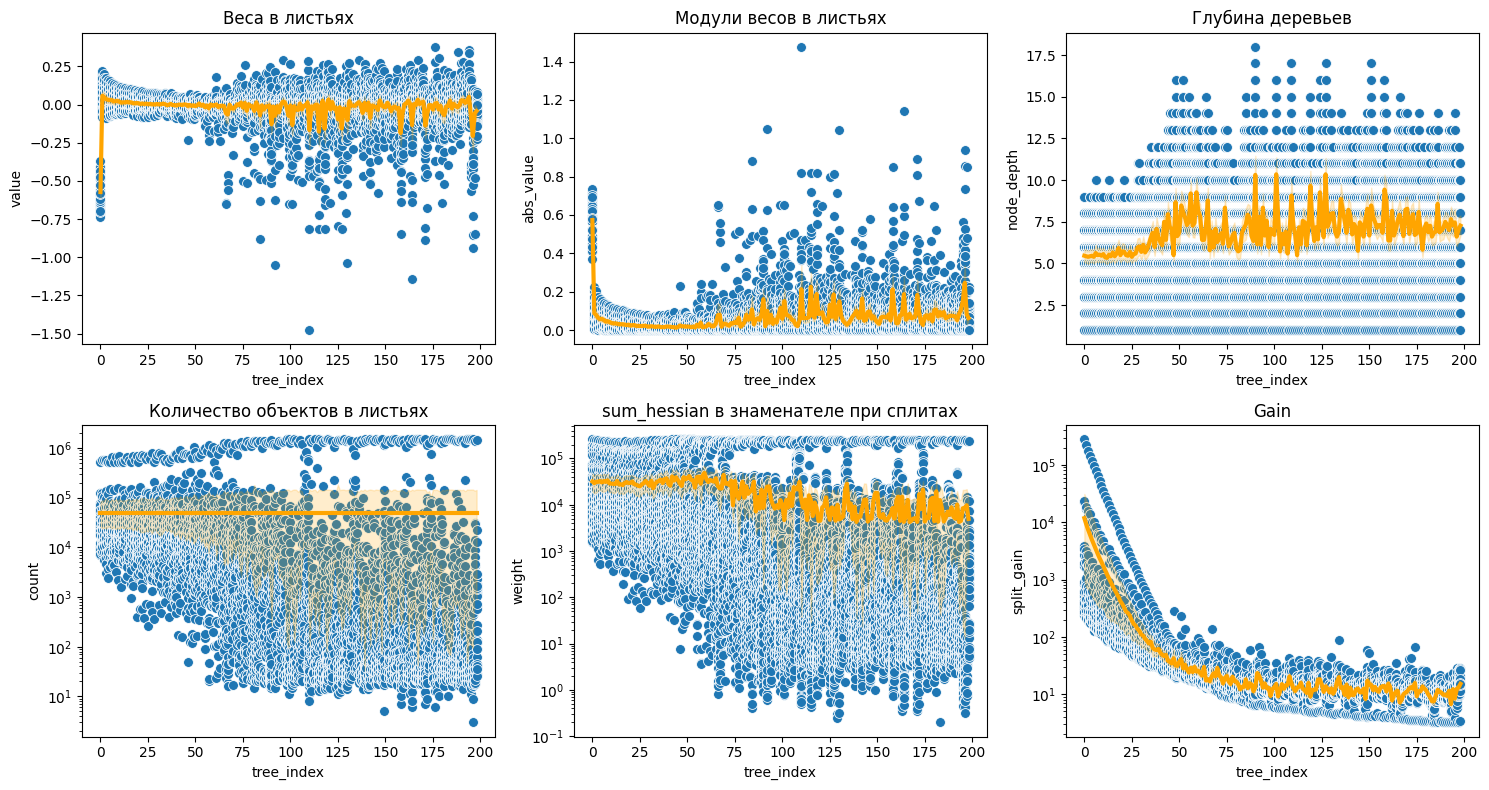

In [25]:
plot_ensemble_profile(t)

Как раз на картинке gain плавно спускается, а еще мало объектов в листьях порой.Надо увеличить их минимум.

In [26]:
t[t['node_depth'] == 1]['split_feature'].value_counts()[:5]

split_feature
order_day_num                44
days_since_last_order        22
order_day_diff_mean          14
to_cart_max_freq_category    13
click_max_freq_category       8
Name: count, dtype: int64

In [28]:
t[t['node_depth'] == 1][t[t['node_depth'] == 1]['split_feature'] == 'order_day_num']

,tree_index,node_depth,node_index,left_child,right_child,parent_index,split_feature,split_gain,threshold,decision_type,missing_direction,missing_type,value,weight,count,abs_value
1037,17,1,17-S0,17-S1,17-S2,None,order_day_num,9451.099609,1.5,<=,left,None,0.0,0.0,1499747,0.0
1159,19,1,19-S0,19-S1,19-S2,None,order_day_num,6536.750000,1.5,<=,left,None,0.0,0.0,1499747,0.0
1220,20,1,20-S0,20-S2,20-S1,None,order_day_num,5387.520020,1.5,<=,left,None,0.0,0.0,1499747,0.0
1342,22,1,22-S0,22-S2,22-S1,None,order_day_num,3734.530029,1.5,<=,left,None,0.0,0.0,1499747,0.0
1403,23,1,23-S0,23-S1,23-S2,None,order_day_num,3114.800049,2.5,<=,left,None,0.0,0.0,1499747,0.0
1464,24,1,24-S0,24-S1,24-S2,None,order_day_num,2574.050049,2.5,<=,left,None,0.0,0.0,1499747,0.0
1647,27,1,27-S0,27-S1,27-S2,None,order_day_num,1519.099976,2.5,<=,left,None,0.0,0.0,1499747,0.0
1769,29,1,29-S0,29-S2,29-S1,None,order_day_num,1070.880005,2.5,<=,left,None,0.0,0.0,1499747,0.0
1891,31,1,31-S0,31-S1,31-S2,None,order_day_num,774.745972,3.5,<=,left,None,0.0,0.0,1499747,0.0
1952,32,1,32-S0,32-S2,32-S1,None,order_day_num,648.572998,1.5,<=,left,None,0.0,0.0,1499747,0.0


In [129]:
def plot_feature_depth(t, top_k=20):
    t_prep = t.copy()
    t_prep.split_feature = t_prep.split_feature.astype('category')
    t_prep = (
        t_prep.query('~split_feature.isnull()')
        .groupby(['node_depth', 'split_feature'], observed=True)
        .size()
        .to_frame('cnt')
        .reset_index()
    )
    t_prep.cnt = t_prep.cnt / 2**(t_prep.node_depth - 1)
    t_prep = t_prep.pivot_table(values='cnt', columns='node_depth', index='split_feature')
    median_cnt = t_prep.sum(axis=1)
    idx = np.argsort(median_cnt)[::-1][:top_k]
    
    sns.heatmap(t_prep.iloc[idx], cmap='coolwarm', annot=False, robust=True)
    plt.gcf().set_size_inches(6, top_k/6 + 1)

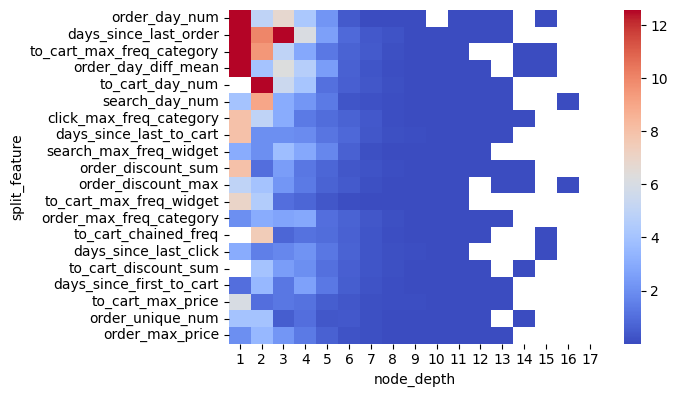

In [117]:
plot_feature_depth(t, top_k=20)

Значения шапа действительно подтверждают наблюдения выше. Часть фичей очень часто используются у корней.

In [131]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val)

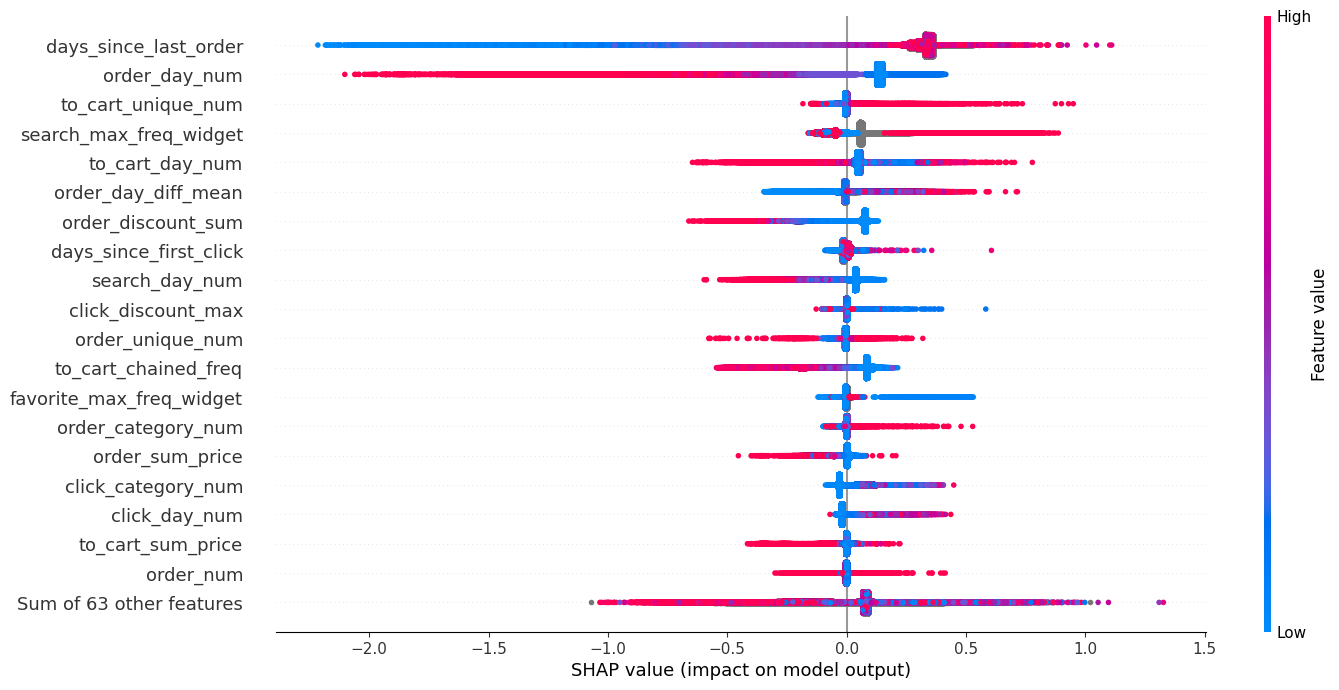

In [147]:
shap.plots.beeswarm(shap_values[:, :, 0], max_display=20, order=shap.Explanation.abs.max(0), plot_size=(15, 8))

Топ 20 фичей как будто неплохо отображают данные. Часто фича однонаправленно коррелирует с таргетом - то есть при уменьшении фичи таргет увеличивается или наоборот.

In [105]:
X_tr_1 = X_tr[(X_tr['days_since_last_order'].isna() + (X_tr['days_since_last_order'] > 40)) * (X_tr['order_day_num'].isna() + (X_tr['order_day_num'] <= 5))]
y_tr_1 = y_tr[(X_tr['days_since_last_order'].isna() + (X_tr['days_since_last_order'] > 40)) * (X_tr['order_day_num'].isna() + (X_tr['order_day_num'] <= 5))]
X_tr_2 = X_tr[(~X_tr['days_since_last_order'].isna() * (X_tr['days_since_last_order'] <= 40)) * (X_tr['order_day_num'].isna() + (X_tr['order_day_num'] <= 5))]
y_tr_2 = y_tr[(~X_tr['days_since_last_order'].isna() * (X_tr['days_since_last_order'] <= 40)) * (X_tr['order_day_num'].isna() + (X_tr['order_day_num'] <= 5))]
X_tr_3 = X_tr[(X_tr['days_since_last_order'].isna() + (X_tr['days_since_last_order'] > 40)) * (~X_tr['order_day_num'].isna() * (X_tr['order_day_num'] > 5))]
y_tr_3 = y_tr[(X_tr['days_since_last_order'].isna() + (X_tr['days_since_last_order'] > 40)) * (~X_tr['order_day_num'].isna() * (X_tr['order_day_num'] > 5))]
X_tr_4 = X_tr[(~X_tr['days_since_last_order'].isna() * (X_tr['days_since_last_order'] <= 40)) * (~X_tr['order_day_num'].isna() * (X_tr['order_day_num'] > 5))]
y_tr_4 = y_tr[(~X_tr['days_since_last_order'].isna() * (X_tr['days_since_last_order'] <= 40)) * (~X_tr['order_day_num'].isna() * (X_tr['order_day_num'] > 5))]

X_val_1 = X_val[(X_val['days_since_last_order'].isna() + (X_val['days_since_last_order'] > 40)) * (X_val['order_day_num'].isna() + (X_val['order_day_num'] <= 5))]
y_val_1 = y_val[(X_val['days_since_last_order'].isna() + (X_val['days_since_last_order'] > 40)) * (X_val['order_day_num'].isna() + (X_val['order_day_num'] <= 5))]
X_val_2 = X_val[(~X_val['days_since_last_order'].isna() * (X_val['days_since_last_order'] <= 40)) * (X_val['order_day_num'].isna() + (X_val['order_day_num'] <= 5))]
y_val_2 = y_val[(~X_val['days_since_last_order'].isna() * (X_val['days_since_last_order'] <= 40)) * (X_val['order_day_num'].isna() + (X_val['order_day_num'] <= 5))]
X_val_3 = X_val[(X_val['days_since_last_order'].isna() + (X_val['days_since_last_order'] > 40)) * (~X_val['order_day_num'].isna() * (X_val['order_day_num'] > 5))]
y_val_3 = y_val[(X_val['days_since_last_order'].isna() + (X_val['days_since_last_order'] > 40)) * (~X_val['order_day_num'].isna() * (X_val['order_day_num'] > 5))]
X_val_4 = X_val[(~X_val['days_since_last_order'].isna() * (X_val['days_since_last_order'] <= 40)) * (~X_val['order_day_num'].isna() * (X_val['order_day_num'] > 5))]
y_val_4 = y_val[(~X_val['days_since_last_order'].isna() * (X_val['days_since_last_order'] <= 40)) * (~X_val['order_day_num'].isna() * (X_val['order_day_num'] > 5))]


In [114]:
lgb_tr1 = lgb.Dataset(X_tr_1.drop(['days_since_last_order', 'order_day_num'], axis=1), y_tr_1, free_raw_data=False)#, categorical_feature=categorical_features)
lgb_val1 = lgb.Dataset(X_val_1.drop(['days_since_last_order', 'order_day_num'], axis=1), y_val_1, free_raw_data=False)#, reference=lgb_tr)
lgb_tr2 = lgb.Dataset(X_tr_2.drop(['days_since_last_order', 'order_day_num'], axis=1), y_tr_2, free_raw_data=False)#, categorical_feature=categorical_features)
lgb_val2 = lgb.Dataset(X_val_2.drop(['days_since_last_order', 'order_day_num'], axis=1), y_val_2, free_raw_data=False)#, reference=lgb_tr)
lgb_tr3 = lgb.Dataset(X_tr_3.drop(['days_since_last_order', 'order_day_num'], axis=1), y_tr_3, free_raw_data=False)#, categorical_feature=categorical_features)
lgb_val3 = lgb.Dataset(X_val_3.drop(['days_since_last_order', 'order_day_num'], axis=1), y_val_3, free_raw_data=False)#, reference=lgb_tr)
lgb_tr4 = lgb.Dataset(X_tr_4.drop(['days_since_last_order', 'order_day_num'], axis=1), y_tr_4, free_raw_data=False)#, categorical_feature=categorical_features)
lgb_val4 = lgb.Dataset(X_val_4.drop(['days_since_last_order', 'order_day_num'], axis=1), y_val_4, free_raw_data=False)#, reference=lgb_tr)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'eta': 0.05,
    'lambda': 1e-3,
    'early_stopping_round': 40,
    'seed': 42,
    'num_threads': 0,
    'verbosity': 1,
    'max_depth': -1,
    'min_data_in_leaf': 50
}

In [115]:
model1 = lgb.train(
    params, lgb_tr1, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr1, lgb_val1],
)

[LightGBM] [Info] Number of positive: 269715, number of negative: 887421
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.281131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14686
[LightGBM] [Info] Number of data points in the train set: 1157136, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.233088 -> initscore=-1.190954
[LightGBM] [Info] Start training from score -1.190954
Training until validation scores don't improve for 40 rounds
Did not meet early stopping. Best iteration is:
[187]	train's auc: 0.630854	valid's auc: 0.626886


In [116]:
model2 = lgb.train(
    params, lgb_tr2, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr2, lgb_val2],
)

[LightGBM] [Info] Number of positive: 171590, number of negative: 85196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.122390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15317
[LightGBM] [Info] Number of data points in the train set: 256786, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.668222 -> initscore=0.700153
[LightGBM] [Info] Start training from score 0.700153
Training until validation scores don't improve for 40 rounds
Did not meet early stopping. Best iteration is:
[200]	train's auc: 0.712448	valid's auc: 0.689429


In [117]:
model3 = lgb.train(
    params, lgb_tr3, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr3, lgb_val3],
)

[LightGBM] [Info] Number of positive: 1778, number of negative: 929
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12469
[LightGBM] [Info] Number of data points in the train set: 2707, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.656816 -> initscore=0.649136
[LightGBM] [Info] Start training from score 0.649136
Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[3]	train's auc: 0.765088	valid's auc: 0.563168


In [118]:
model4 = lgb.train(
    params, lgb_tr4, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr4, lgb_val4],
)

[LightGBM] [Info] Number of positive: 75169, number of negative: 7949
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041654 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15669
[LightGBM] [Info] Number of data points in the train set: 83118, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.904365 -> initscore=2.246693
[LightGBM] [Info] Start training from score 2.246693
Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[98]	train's auc: 0.804565	valid's auc: 0.743989


In [10]:
test_data_pd = test_data.to_pandas()
X_test = test_data_pd.drop(['user_id', 'days_since_first_order'], axis=1)

In [119]:
part1 = (X_test['days_since_last_order'].isna() + (X_test['days_since_last_order'] > 40)) * (X_test['order_day_num'].isna() + (X_test['order_day_num'] <= 5))
part2 = (~X_test['days_since_last_order'].isna() * (X_test['days_since_last_order'] <= 40)) * (X_test['order_day_num'].isna() + (X_test['order_day_num'] <= 5))
part3 = (X_test['days_since_last_order'].isna() + (X_test['days_since_last_order'] > 40)) * (~X_test['order_day_num'].isna() * (X_test['order_day_num'] > 5))
part4 = (~X_test['days_since_last_order'].isna() * (X_test['days_since_last_order'] <= 40)) * (~X_test['order_day_num'].isna() * (X_test['order_day_num'] > 5))

X_test_1 = X_test[part1]
X_test_2 = X_test[part2]
X_test_3 = X_test[part3]
X_test_4 = X_test[part4]

In [120]:
test_data_pd['predict'] = 0.0

In [121]:
test_data_pd['predict'][part1] = model1.predict(X_test_1.drop(['days_since_last_order', 'order_day_num'], axis=1))
test_data_pd['predict'][part2] = model2.predict(X_test_2.drop(['days_since_last_order', 'order_day_num'], axis=1))
test_data_pd['predict'][part3] = model3.predict(X_test_3.drop(['days_since_last_order', 'order_day_num'], axis=1))
test_data_pd['predict'][part4] = model4.predict(X_test_4.drop(['days_since_last_order', 'order_day_num'], axis=1))

In [123]:
test_data_pd[['user_id', 'predict']].to_csv('baseline_9sep_submission.csv', index=False)

In [124]:
from IPython.display import FileLink
FileLink(r'./baseline_9sep_submission.csv')

/kaggle/working/baseline_9sep_submission.csv

In [12]:
model = lgb.train(
    params, lgb_tr, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr, lgb_val],
)

[LightGBM] [Info] Number of positive: 518252, number of negative: 981495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.684770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15772
[LightGBM] [Info] Number of data points in the train set: 1499747, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.345560 -> initscore=-0.638615
[LightGBM] [Info] Start training from score -0.638615
Training until validation scores don't improve for 40 rounds
Did not meet early stopping. Best iteration is:
[199]	train's auc: 0.766003	valid's auc: 0.763599


# Понижение размерности

### Поглядим umap + shap

In [137]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val)

In [13]:
import pickle 
  
# with open('shap_values.pkl', 'wb') as file: 
#     pickle.dump(shap_values , file)

with open('shap_values.pkl', 'rb') as file: 
    shap_values = pickle.load(file)

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

In [15]:
_, subsample_id = next(StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=0).split(X_val, y_val))

In [16]:
import plotly.express as px

mapper = umap.umap_.UMAP(n_jobs=4, n_neighbors=30, metric='euclidean', random_state=1)
emb = mapper.fit_transform(shap_values[subsample_id].values[:, :, 0])

embs = pd.DataFrame({
    'x': emb[:, 0],
    'y': emb[:, 1],
    'color': y_val.values[subsample_id]
})
fig = px.scatter(data_frame=embs, x='x', y='y', color='color')
fig.update_layout(width=800)

### Видна часть кластеров, но они какие-то плохие. Использовать эту информацию для бустингов кажется бессмысленным. Попробую просто понизить размерность фичей и прогнать модель так.

Отшкалирую данные, и в юмап.

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [33]:
X_tr_transformed = scaler.fit_transform(X_tr.fillna(-1))
X_val_transformed = scaler.transform(X_val.fillna(-1))

In [34]:
_, subsample_id = next(StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=0).split(X_tr_transformed, y_tr))

In [37]:
mapper = umap.umap_.UMAP(n_jobs=4, n_neighbors=30, metric='euclidean', random_state=1, n_components=30)
mapper.fit(X_tr_transformed[subsample_id])

UMAP(n_components=30, n_jobs=1, n_neighbors=30, random_state=1, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

In [ ]:
X_tr_umap = mapper.transform(X_tr_transformed)
X_val_umap = mapper.transform(X_val_transformed)

In [ ]:
lgb_tr = lgb.Dataset(X_tr_umap, y_tr, free_raw_data=False)
lgb_val = lgb.Dataset(X_val_umap, y_val, free_raw_data=False)

model = lgb.train(
    params, lgb_tr, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr, lgb_val],
)

In [ ]:
X_test_transformed = scaler.transform(X_test.fillna(-1))

In [ ]:
test_data_pd['predict'] = model.predict(X_test_transformed)

In [ ]:
test_data_pd[['user_id', 'predict']].to_csv('baseline_9sep_submission.csv', index=False)

### получилась фигня. Скорее всего у меня недостаточно хороших фичей, и часть абсолютно мусорных.

# Кластеризация

### Попробую кластеризовать данные и использовать это как фичу. На картинках юмап+шап было видно +- норм 7 тучек, то есть кластеров. Задам столько же для Kmeans.

In [41]:
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

In [52]:
imputer = SimpleImputer(strategy='median')
X_tr_imp = imputer.fit_transform(X_tr)
scaler = MinMaxScaler()
X_tr_new = scaler.fit_transform(X_tr_imp)
means = KMeans(n_clusters=7, random_state=0, n_init="auto").fit(X_tr_new)

In [53]:
X_val_new = imputer.transform(scaler.transform(X_val))
X_tr_clusters = means.predict(X_tr_new)
X_val_clusters = means.predict(X_val_new)

In [70]:
X_tr_new = np.concatenate((X_tr_new, X_tr_clusters.reshape(-1, 1)), axis=1)
X_val_new = np.concatenate((X_val_new, X_val_clusters.reshape(-1, 1)), axis=1)

In [73]:
categorical_features = [82]
lgb_tr = lgb.Dataset(X_tr_new, label=y_tr, free_raw_data=False, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val_new, label=y_val, free_raw_data=False, categorical_feature=categorical_features)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'eta': 0.1,
    'lambda': 1e-3,
    'early_stopping_round': 40,
    'seed': 42,
    'num_threads': 0,
    'verbosity': 1
}

In [74]:
model = lgb.train(
    params, lgb_tr, num_boost_round=200, # basic
    valid_names=['train', 'valid'], valid_sets=[lgb_tr, lgb_val],
)

[LightGBM] [Info] Number of positive: 518252, number of negative: 981495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.492806 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15655
[LightGBM] [Info] Number of data points in the train set: 1499747, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.345560 -> initscore=-0.638615
[LightGBM] [Info] Start training from score -0.638615
Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[82]	train's auc: 0.763484	valid's auc: 0.761892


In [77]:
X_test = test_data_pd.drop(['user_id', 'days_since_first_order'], axis=1)
X_test_new = imputer.transform(scaler.transform(X_test))
X_test_clusters = means.predict(X_test_new)
X_test_new = np.concatenate((X_test_new, X_test_clusters.reshape(-1, 1)), axis=1)

In [82]:
test_data_pd['predict'] = model.predict(X_test_new)

In [83]:
test_data_pd[['user_id', 'predict']].to_csv('baseline_cluster_submission.csv', index=False)

In [84]:
test_data_pd = test_data_pd.drop('predict', axis=1)

### Количество деревьев в бустинге стало намного меньше. В целом неплохо - меньше переобучения. Но на практике не дало улучшения скора.

# KNN

### Не использовал за ненадобностью. Так как часть фичей категориальные, а еще много пропусков, решил не использовать KNN. Он тоже метрический метод как и KMeans, и навряд ли сработае лучше. Так что в текущих реалиях использовать нецелесообразно. (плюс кластеризация и понижение размерности показали, что разбиение на основе метрики наданных не способствует улучшению скора)

# Тюнинг

In [85]:
import optuna
from sklearn.metrics import roc_auc_score

In [87]:
def objective(trial):
    learning_rate = trial.suggest_loguniform('learning_rate', 0.001, 0.2)
    num_leaves = trial.suggest_int('num_leaves', 8, 100)

    params = {
    'objective': 'binary',
    'metric': 'auc',
    'eta': learning_rate,
    'lambda': 1e-3,
    'seed': 42,
    'num_threads': 0,
    'verbosity': 0,
    'num_leaves': num_leaves
    }

    lgb_tr = lgb.Dataset(X_tr, y_tr, free_raw_data=False)
    
    model = lgb.train(
        params, lgb_tr, num_boost_round=200,
    )
    
    # Predict and evaluate
    y_pred = model.predict(X_val)
    roc_score = roc_auc_score(y_val, y_pred)
    return roc_score

study = optuna.create_study(direction='maximize')

# Optimize the objective function
study.optimize(objective, n_trials=50)

# Print the best parameters and best score
print("Best parameters found: ", study.best_params)
print("Best roc_auc: {:.2f}".format(study.best_value))

[I 2025-04-09 17:18:41,323] A new study created in memory with name: no-name-99cfcf5b-5939-47a4-b564-3ae26273f757
[I 2025-04-09 17:19:26,586] Trial 0 finished with value: 0.7525852771264443 and parameters: {'learning_rate': 0.002132168526502371, 'num_leaves': 12}. Best is trial 0 with value: 0.7525852771264443.
[I 2025-04-09 17:20:31,839] Trial 1 finished with value: 0.7637091050081672 and parameters: {'learning_rate': 0.032378712403121526, 'num_leaves': 64}. Best is trial 1 with value: 0.7637091050081672.
[I 2025-04-09 17:21:45,396] Trial 2 finished with value: 0.7618509553732133 and parameters: {'learning_rate': 0.010796689338942034, 'num_leaves': 66}. Best is trial 1 with value: 0.7637091050081672.
[I 2025-04-09 17:22:50,652] Trial 3 finished with value: 0.7618178913643653 and parameters: {'learning_rate': 0.014161072193626782, 'num_leaves': 43}. Best is trial 1 with value: 0.7637091050081672.
[I 2025-04-09 17:24:12,077] Trial 4 finished with value: 0.7598249631235462 and parameters

KeyboardInterrupt: 

In [12]:
lgb_tr = lgb.Dataset(train_data_pd.drop(['user_id', 'target', 'days_since_first_order'], axis=1), label=train_data_pd.target, free_raw_data=False)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'eta': 0.12267070991041436,
    'lambda': 1e-3,
    'seed': 42,
    'num_threads': 0,
    'verbosity': 1,
    'num_leaves': 28
}

In [13]:
model = lgb.train(
    params, lgb_tr, num_boost_round=120, # basic
)

[LightGBM] [Info] Number of positive: 647575, number of negative: 1227381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.523237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15798
[LightGBM] [Info] Number of data points in the train set: 1874956, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.345381 -> initscore=-0.639403
[LightGBM] [Info] Start training from score -0.639403


In [14]:
test_data_pd['predict'] = model.predict(X_test)
test_data_pd[['user_id', 'predict']].to_csv('baseline_lgbtun2_submission.csv', index=False)
test_data_pd = test_data_pd.drop('predict', axis=1)

### Попробуем катбуст. Вдруг сработает лучше.

In [16]:
train_pool = catboost.Pool(
    train_data_pd.drop(['user_id', 'target', 'days_since_first_order'], axis=1),
    label=train_data_pd['target']
)

params = {
    'iterations': 100,
    'depth': 8, 
    'random_state': 1,
    'loss_function': 'Logloss',
    'task_type': 'CPU',
    'eta': 0.1,
    'verbose': 0
}

In [17]:
model = catboost.CatBoost(params)
model.fit(
    train_pool
)

In [18]:
test_data_pd['predict'] = model.predict(X_test, prediction_type="Probability")[:, 1]
test_data_pd[['user_id', 'predict']].to_csv('baseline_cat2_submission.csv', index=False)
test_data_pd = test_data_pd.drop('predict', axis=1)